# Lab 4 — Part 1: Optimizing LLM Inference with KV-Caching

In this notebook you will extend a nanoGPT-style codebase to implement **KV-caching**,
then benchmark the speedup it provides during autoregressive text generation.

> **Tip:** Use the **CPU** runtime for all development and debugging (Steps 1–3).
> Switch to the **T4 GPU** runtime only when generating your final benchmark graphs.

## Setup

In [ ]:
import math
import time
from dataclasses import dataclass
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


---
## Step 1 — Understanding Self-Attention (15 points)

Before implementing KV-caching, make sure you understand the baseline transformer.
Watch Andrej Karpathy's [*Let's build GPT: from scratch*](https://www.youtube.com/watch?v=kCc8FmEb1nY) and answer Q1–Q4.

---
### Q1 (3 pt)
In Karpathy's single-head self-attention implementation, what are the shapes of the
**q**, **k**, and **v** matrices?
Express your answer in terms of `B`, `T`, `C`, `vocab_size`, `block_size`, `num_heads`.

**Answer Q1:**

q - BxTxC
k - BxTxC
v - BxTxC

---
### Q2 (4 pt)
Complete the code block below to apply the causal mask to the raw attention scores `wei`.
Recall that `mask[i, j] == True` whenever token `i` should **not** attend to token `j`.

In [ ]:
# --- Q2: fill in the two lines marked TODO ---
B, T, C = 2, 8, 16
block_size = T

# Dummy q and k for illustration
q = torch.randn(B, T, C)
k = torch.randn(B, T, C)

tril = torch.tril(torch.ones(block_size, block_size))
mask = tril[:T, :T] == 0
wei  = q @ k.transpose(-2, -1) * C**(-0.5)

# TODO: apply the causal mask to wei
# wei = ...
wei = wei.masked_fill(tril[:T, :T] == 0, float('-inf'))

# TODO: apply softmax over the last dimension
# wei = ...
wei = F.softmax(wei, dim=-1)

print('wei shape:', wei.shape)
print('First row of wei[0] (should be 1.0 at position 0, 0.0 elsewhere in upper triangle):',
      wei[0, 0].detach())

wei shape: torch.Size([2, 8, 8])
First row of wei[0] (should be 1.0 at position 0, 0.0 elsewhere in upper triangle): tensor([1., 0., 0., 0., 0., 0., 0., 0.])


---
### Q3 (3 pt)
What do you expect the value of `mask` to look like when computing the token at position `i`?
Describe which entries are `True` and which are `False`.

**Answer Q3:**

All values before and at i will be True, and everything after i will be False.

Example:
If T=8 and i=4
mask = [False, False, False, False, True, True, True, True]

---
### Q4 (5 pt)
Write code to extract the mask for computing **token at position `i`** from `tril`.
The result should be a 1-D boolean tensor of length `i+1` (or a scalar row from `tril`).

In [ ]:
# --- Q4: extract the mask row for position i ---
block_size = 8
tril = torch.tril(torch.ones(block_size, block_size))

i = 3   # example position; your code should work for any i in [0, block_size)

# TODO: set mask_i to the boolean mask for token position i
# mask_i should be True for positions that token i CANNOT attend to (future tokens)
mask_i = [False if idx <=i else True for idx in range(block_size)]

print(f'mask for token i={i}:', mask_i)

mask for token i=3: [False, False, False, False, True, True, True, True]


---
## Baseline GPT Implementation

The cells below define a standard nanoGPT model (`GPT`) that we will use as our baseline.
**Do not modify this code.** You will add KV-caching in a separate class hierarchy below.

In [ ]:
# ── Model configuration ───────────────────────────────────────────────────────

@dataclass
class GPTConfig:
    vocab_size:  int   = 65      # Shakespeare character-level vocab
    block_size:  int   = 256     # maximum context length
    n_layer:     int   = 2
    n_head:      int   = 8       # h
    n_embd:      int   = 2048
    dropout:     float = 0.0     # 0 for inference

    @property
    def head_size(self) -> int:  # dk
        return self.n_embd // self.n_head

In [ ]:
# ── Baseline transformer components ──────────────────────────────────────────

class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention (no KV-cache)."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head    = config.n_head
        self.head_size = config.head_size

        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.attn_drop = nn.Dropout(config.dropout)
        self.resid_drop = nn.Dropout(config.dropout)

        # Causal mask — registered as a buffer (not a parameter)
        self.register_buffer(
            'bias',
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        nh, hs  = self.n_head, self.head_size

        # Compute Q, K, V and split heads
        qkv = self.c_attn(x)                                    # (B, T, 3C)
        q, k, v = qkv.split(C, dim=2)                           # each (B, T, C)
        q = q.view(B, T, nh, hs).transpose(1, 2)                # (B, nh, T, hs)
        k = k.view(B, T, nh, hs).transpose(1, 2)
        v = v.view(B, T, nh, hs).transpose(1, 2)

        # Scaled dot-product attention with causal mask
        scale = hs ** -0.5
        att   = (q @ k.transpose(-2, -1)) * scale               # (B, nh, T, T)
        att   = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att   = F.softmax(att, dim=-1)
        att   = self.attn_drop(att)

        y = att @ v                                             # (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C)        # (B, T, C)
        return self.resid_drop(self.c_proj(y))


class MLP(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Block(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.mlp  = MLP(config)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class GPT(nn.Module):
    """Baseline GPT (no KV-cache)."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict({
            'wte': nn.Embedding(config.vocab_size, config.n_embd),
            'wpe': nn.Embedding(config.block_size, config.n_embd),
            'drop': nn.Dropout(config.dropout),
            'h': nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            'ln_f': nn.LayerNorm(config.n_embd),
        })
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        B, T = idx.shape
        assert T <= self.config.block_size, 'Sequence longer than block_size'
        pos = torch.arange(T, device=idx.device)
        x = self.transformer['drop'](
            self.transformer['wte'](idx) + self.transformer['wpe'](pos)
        )
        for block in self.transformer['h']:
            x = block(x)
        x = self.transformer['ln_f'](x)
        return self.lm_head(x)                                 # (B, T, vocab_size)

    @torch.no_grad()
    def generate(self, idx: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
        """Autoregressive generation WITHOUT KV-cache."""
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.config.block_size:]        # crop to block_size
            logits   = self(idx_cond)                          # full forward pass
            logits   = logits[:, -1, :]                        # last token only
            probs    = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx      = torch.cat([idx, idx_next], dim=1)
        return idx


# Quick sanity check
cfg   = GPTConfig()
model = GPT(cfg).to(device)
dummy = torch.zeros(1, 10, dtype=torch.long, device=device)
out   = model(dummy)
print('GPT output shape:', out.shape)   # should be (1, 10, 65)

GPT output shape: torch.Size([1, 10, 65])


---
## Step 2 — Benchmarking Baseline Token Generation (15 points)

We measure **per-token generation time** as a function of the prompt length.
Because the baseline re-runs the full sequence at every step, generation time
should grow roughly linearly with sequence length.

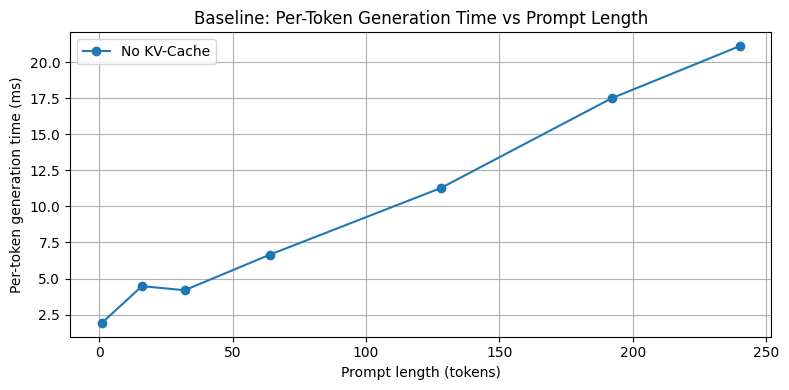

Saved baseline_benchmark.png


In [ ]:
def benchmark_generate(model: GPT, prompt_len: int, gen_tokens: int = 1,
                        num_runs: int = 20) -> float:
    """Return average per-token generation time (ms)."""
    model.eval()
    idx = torch.zeros(1, prompt_len, dtype=torch.long, device=device)

    # Warmup
    for _ in range(3):
        model.generate(idx, max_new_tokens=gen_tokens)

    if device == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(num_runs):
        model.generate(idx, max_new_tokens=gen_tokens)
    if device == 'cuda':
        torch.cuda.synchronize()
    elapsed = (time.perf_counter() - t0) / num_runs * 1e3  # ms
    return elapsed / gen_tokens   # per-token


cfg   = GPTConfig()
model = GPT(cfg).to(device)

prompt_lengths = [1, 16, 32, 64, 128, 192, 240]
baseline_times = [benchmark_generate(model, L) for L in prompt_lengths]

plt.figure(figsize=(8, 4))
plt.plot(prompt_lengths, baseline_times, marker='o', label='No KV-Cache')
plt.xlabel('Prompt length (tokens)')
plt.ylabel('Per-token generation time (ms)')
plt.title('Baseline: Per-Token Generation Time vs Prompt Length')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('baseline_benchmark.png', dpi=150)
plt.show()
print('Saved baseline_benchmark.png')

### Q5 (5 pt)
Submit the graph produced above (`baseline_benchmark.png`).

### Q6 (10 pt)
What key trends do you observe in the per-token generation time as the prompt grows?
Explain *why* this trend occurs based on what the model computes at each step.

**Answer Q6:**

The per token generation time increases linearly, as the sequence length increases.

This increase is because, each token has to attend all its preceeding tokens (self attention), hence as the sequence length increases, the token generation time increases, with an increase in the sequence length.

---
## Step 3 — Implementing and Benchmarking KV-Caching (50 points)

### Background

Without KV-caching, the model recomputes **K** and **V** for the entire sequence at every
generation step — even though only the newly generated token changes.

KV-caching avoids this by storing the K and V tensors computed in the **prefill** step
and re-using them in every subsequent **decode** step:

| Step | What the model computes |
|------|------------------------|
| **Prefill** | Q, K, V for full prompt → cache K, V |
| **Decode** | Q, K_new, V_new for one token → append to cached K, V → attend |

Because the decode step only processes **one** token, the per-token time stays
roughly constant regardless of context length.

---
### Your task

Fill in every block marked:
```
##### Solution Block <ID> #####
...
##### End Solution Block <ID> #####
```
Use `output_check()` at the end of this section to validate your implementation.

In [ ]:
# ── KV-cache–aware self-attention ─────────────────────────────────────────────

class CausalSelfAttentionWithCache(nn.Module):
    """
    Multi-head causal self-attention with optional KV-cache support.

    forward() arguments
    -------------------
    x        : (B, T, C)  — input token embeddings
    past_kv  : Optional tuple (past_k, past_v), each (B, nh, past_T, hs)
               None on the first (prefill) call.

    forward() returns
    -----------------
    y           : (B, T, C)  — attention output
    present_kv  : tuple (k, v), each (B, nh, past_T + T, hs)
                  The full updated cache to pass to the next decode step.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head    = config.n_head
        self.head_size = config.head_size
        self.n_embd    = config.n_embd

        self.c_attn     = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj     = nn.Linear(config.n_embd, config.n_embd)
        self.attn_drop  = nn.Dropout(config.dropout)
        self.resid_drop = nn.Dropout(config.dropout)

        self.register_buffer(
            'bias',
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(
        self,
        x: torch.Tensor,
        past_kv: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
    ) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:

        B, T, C = x.shape
        nh, hs  = self.n_head, self.head_size

        # Project and split into Q, K, V
        qkv = self.c_attn(x)
        q, k, v = qkv.split(C, dim=2)
        q = q.view(B, T, nh, hs).transpose(1, 2)   # (B, nh, T, hs)
        k = k.view(B, T, nh, hs).transpose(1, 2)
        v = v.view(B, T, nh, hs).transpose(1, 2)

        ##### Solution Block SA-1 #####
        # KV-cache: concatenate past keys/values with the current ones.
        #
        # If past_kv is not None:
        #   - past_kv is a tuple (past_k, past_v), each shape (B, nh, past_T, hs)
        #   - Concatenate past_k with k along dim=2  →  k becomes (B, nh, past_T + T, hs)
        #   - Do the same for v.
        #
        # Always set present_kv = (k, v)  (the full updated cache to return).


        if past_kv is not None:
            past_k, past_v = past_kv
            k = torch.cat([past_k, k], dim=2)
            v = torch.cat([past_v, v], dim=2)

        present_kv = (k, v)   # ← replace

        ##### End Solution Block SA-1 #####

        # Total key/value sequence length after cache concatenation
        kv_T = k.shape[2]

        # Scaled dot-product attention
        scale = hs ** -0.5
        att   = (q @ k.transpose(-2, -1)) * scale   # (B, nh, T, kv_T)

        ##### Solution Block SA-2 #####
        # Apply the causal mask.
        #
        # The mask must cover (T rows) × (kv_T cols).
        # Token at absolute position (past_T + i) may attend to positions 0 … past_T + i.
        # Use self.bias, which has shape (1, 1, block_size, block_size).
        #
        # Hint: self.bias[:, :, (kv_T - T):kv_T, :kv_T] selects the correct sub-matrix.
        # Mask out positions where bias == 0 with float('-inf').

        # att   = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = att.masked_fill(self.bias[:, :, (kv_T - T):kv_T, :kv_T] == 0, float('-inf'))   # ← replace this comment with your code

        ##### End Solution Block SA-2 #####

        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)

        y = att @ v                                             # (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_drop(self.c_proj(y))

        return y, present_kv

In [ ]:
# ── KV-cache–aware transformer block ─────────────────────────────────────────

class BlockWithCache(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1  = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttentionWithCache(config)
        self.ln2  = nn.LayerNorm(config.n_embd)
        self.mlp  = MLP(config)

    def forward(
        self,
        x: torch.Tensor,
        past_kv: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
    ) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        attn_out, present_kv = self.attn(self.ln1(x), past_kv=past_kv)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        return x, present_kv

In [ ]:
# ── Full GPT model with KV-cache support ──────────────────────────────────────

class GPTWithCaching(nn.Module):
    """
    GPT model extended with KV-caching for efficient autoregressive generation.

    Weights are copied from a pre-built GPT instance so that output_check()
    can verify that cached and non-cached generation produce identical results.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict({
            'wte':  nn.Embedding(config.vocab_size, config.n_embd),
            'wpe':  nn.Embedding(config.block_size, config.n_embd),
            'drop': nn.Dropout(config.dropout),
            'h':    nn.ModuleList([BlockWithCache(config) for _ in range(config.n_layer)]),
            'ln_f': nn.LayerNorm(config.n_embd),
        })
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    @classmethod
    def from_gpt(cls, gpt: GPT) -> 'GPTWithCaching':
        """Copy weights from a baseline GPT model."""
        config  = gpt.config
        model   = cls(config)

        # Copy embedding and output head weights
        model.transformer['wte'].weight.data  = gpt.transformer['wte'].weight.data.clone()
        model.transformer['wpe'].weight.data  = gpt.transformer['wpe'].weight.data.clone()
        model.transformer['ln_f'].weight.data = gpt.transformer['ln_f'].weight.data.clone()
        model.transformer['ln_f'].bias.data   = gpt.transformer['ln_f'].bias.data.clone()
        model.lm_head.weight.data             = gpt.lm_head.weight.data.clone()

        # Copy each block's weights
        for src_block, dst_block in zip(gpt.transformer['h'], model.transformer['h']):
            for name in ['ln1', 'ln2']:
                getattr(dst_block, name).weight.data = getattr(src_block, name).weight.data.clone()
                getattr(dst_block, name).bias.data   = getattr(src_block, name).bias.data.clone()
            # Attention projections
            for proj in ['c_attn', 'c_proj']:
                getattr(dst_block.attn, proj).weight.data = getattr(src_block.attn, proj).weight.data.clone()
                if getattr(src_block.attn, proj).bias is not None:
                    getattr(dst_block.attn, proj).bias.data = getattr(src_block.attn, proj).bias.data.clone()
            # MLP weights
            for i, layer in enumerate(src_block.mlp.net):
                if isinstance(layer, nn.Linear):
                    dst_block.mlp.net[i].weight.data = layer.weight.data.clone()
                    dst_block.mlp.net[i].bias.data   = layer.bias.data.clone()

        return model

    def forward(
        self,
        idx:              torch.Tensor,
        past_key_values:  Optional[List[Optional[Tuple]]] = None,
    ) -> Tuple[torch.Tensor, List[Tuple]]:
        """
        Parameters
        ----------
        idx             : (B, T)  — input token indices
        past_key_values : list of per-layer (past_k, past_v) tuples, or None.
                          Length must equal n_layer.

        Returns
        -------
        logits           : (B, T, vocab_size)
        present_key_values : list of (k, v) tuples — one per layer.
        """
        B, T = idx.shape
        if past_key_values is None:
            past_key_values = [None] * self.config.n_layer

        # Compute starting position for positional embeddings
        past_len = 0 if past_key_values[0] is None else past_key_values[0][0].shape[2]
        pos = torch.arange(past_len, past_len + T, device=idx.device)

        x = self.transformer['drop'](
            self.transformer['wte'](idx) + self.transformer['wpe'](pos)
        )

        present_key_values = []
        for i, block in enumerate(self.transformer['h']):
            x, present_kv = block(x, past_kv=past_key_values[i])
            present_key_values.append(present_kv)

        x      = self.transformer['ln_f'](x)
        logits = self.lm_head(x)
        return logits, present_key_values

    @torch.no_grad()
    def generate_with_cache(
        self,
        idx:            torch.Tensor,
        max_new_tokens: int,
    ) -> torch.Tensor:
        """
        Autoregressive generation WITH KV-cache.

        Algorithm
        ---------
        1. (Prefill) Forward the full prompt through the model.
           Collect the initial KV-cache from all layers.
        2. (Decode) For each new token:
           - Forward only the last generated token (not the whole sequence).
           - Pass the KV-cache; receive the updated cache.
           - Sample the next token and append it.
        """

        ##### Solution Block GEN-1 #####
        # Initialize past_key_values.
        # It should be a list of `None` with one entry per transformer block.
        # (The forward() method already handles None gracefully for the prefill step.)

        # past_key_values = None   # ← replace

        # if past_key_values is None:
        past_key_values = [None] * self.config.n_layer


        ##### End Solution Block GEN-1 #####

        for step in range(max_new_tokens):

            ##### Solution Block GEN-2 #####
            # Efficient generation loop.
            #
            # Step 0  (prefill):  forward the full prompt  idx[:, -block_size:]
            # Step > 0 (decode):  forward only the last token  idx[:, -1:]
            #
            # In both cases:
            #   - Call self.forward(input_tokens, past_key_values=past_key_values)
            #   - Update past_key_values with the returned present_key_values
            #   - Store the returned logits tensor (shape B × 1 × vocab_size)

            if step == 0:
              input_seq = idx[:, -self.config.block_size:]
            else:
              input_seq = idx[:, -1:]

            logits, present_kv = self.forward(input_seq, past_key_values=past_key_values)

            past_key_values = present_kv
            # logits = None   # ← replace
            # logits = logits[:, -1, :]



            ##### End Solution Block GEN-2 #####

            if logits is None:
                raise RuntimeError('Solution Block GEN-2 is not implemented.')

            logits   = logits[:, -1, :]           # (B, vocab_size)
            probs    = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx      = torch.cat([idx, idx_next], dim=1)

        return idx

In [ ]:
# ── Correctness validation ────────────────────────────────────────────────────

def output_check(gpt: GPT, gpt_cached: GPTWithCaching,
                 prompt_len: int = 10, gen_tokens: int = 5,
                 seed: int = 0) -> None:
    """
    Verify that generate() and generate_with_cache() produce identical token sequences
    when starting from the same random seed.
    """
    prompt = torch.zeros(1, prompt_len, dtype=torch.long, device=device)

    torch.manual_seed(seed)
    out_baseline = gpt.generate(prompt.clone(), max_new_tokens=gen_tokens)

    torch.manual_seed(seed)
    out_cached   = gpt_cached.generate_with_cache(prompt.clone(), max_new_tokens=gen_tokens)

    match = torch.equal(out_baseline, out_cached)
    if match:
        print('output_check PASSED ✓  — cached and non-cached outputs are identical.')
    else:
        print('output_check FAILED ✗')
        print('  Baseline :', out_baseline.tolist())
        print('  Cached   :', out_cached.tolist())
        raise AssertionError('KV-cache implementation is incorrect.')


# Build models and run the check
cfg       = GPTConfig()
gpt       = GPT(cfg).to(device).eval()
gpt_cache = GPTWithCaching.from_gpt(gpt).to(device).eval()

output_check(gpt, gpt_cache)

output_check PASSED ✓  — cached and non-cached outputs are identical.


---
### Q7 (40 pt)

For each Solution Block, paste your code below and provide a brief explanation
of what it does and *why* it is correct.

**Solution Block SA-1** — KV-cache concatenation

```python
        ##### Solution Block SA-1 #####
        # KV-cache: concatenate past keys/values with the current ones.
        #
        # If past_kv is not None:
        #   - past_kv is a tuple (past_k, past_v), each shape (B, nh, past_T, hs)
        #   - Concatenate past_k with k along dim=2  →  k becomes (B, nh, past_T + T, hs)
        #   - Do the same for v.
        #
        # Always set present_kv = (k, v)  (the full updated cache to return).
        

        if past_kv is not None:
            past_k, past_v = past_kv
            k = torch.cat([past_k, k], dim=2)
            v = torch.cat([past_v, v], dim=2)

        present_kv = (k, v)   # ← replace

        ##### End Solution Block SA-1 #####
```
*Explanation:*
This block performs an incremental update to the KV cache by concatenating the $k$ and $v$ vectors of the current token with all previously computed vectors along the sequence dimension (dim=2).

It ensures the attention mechanism has access to the full sequence history without re-computing projections ($W_K, W_V$) for past tokens. By returning the concatenated result as present_kv, it maintains a recursive state that allows each subsequent decoding step to build upon the previous one with $O(1)$ projection complexity.

---

**Solution Block SA-2** — Causal mask with cache offset

```python
        ##### Solution Block SA-2 #####
        # Apply the causal mask.
        #
        # The mask must cover (T rows) × (kv_T cols).
        # Token at absolute position (past_T + i) may attend to positions 0 … past_T + i.
        # Use self.bias, which has shape (1, 1, block_size, block_size).
        #
        # Hint: self.bias[:, :, (kv_T - T):kv_T, :kv_T] selects the correct sub-matrix.
        # Mask out positions where bias == 0 with float('-inf').

        # att   = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = att.masked_fill(self.bias[:, :, (kv_T - T):kv_T, :kv_T] == 0, float('-inf'))   # ← replace this comment with your code

        ##### End Solution Block SA-2 #####
```
*Explanation:*
This block ensures that the attention mechanism respects the causal constraint (not looking into the future) when using a KV-cache.Aligning the Mask: Because the attention scores (att) now form a rectangle of size $T \times kv\_T$, we must slice the pre-computed self.bias square to match.The Row Offset: We use (kv_T - T):kv_T to select rows that correspond to our current tokens' actual positions in the total sequence. For example, if we are at step 100 ($kv\_T=100$) and processing 1 new token ($T=1$), we need the 100th row of the mask.The Column Span: We use :kv_T to allow our current tokens to look at all previous tokens stored in the cache plus themselves.Enforcing the Rule: By filling positions where bias == 0 with -inf, we ensure those "future" connections have zero probability after the Softmax step.This logic is what allows the model to handle both the initial prefill (where $T$ is large) and the incremental decoding (where $T=1$) using the same function.

---

**Solution Block GEN-1** — Cache initialization

```python
        ##### Solution Block GEN-1 #####
        # Initialize past_key_values.
        # It should be a list of `None` with one entry per transformer block.
        # (The forward() method already handles None gracefully for the prefill step.)

        # past_key_values = None   # ← replace
        
        # if past_key_values is None:
        past_key_values = [None] * self.config.n_layer
        

        ##### End Solution Block GEN-1 #####
```
*Explanation:*
Initializing past_key_values, of size = nnum_layers

---

**Solution Block GEN-2** — Efficient generation loop

```python
            ##### Solution Block GEN-2 #####
            # Efficient generation loop.
            #
            # Step 0  (prefill):  forward the full prompt  idx[:, -block_size:]
            # Step > 0 (decode):  forward only the last token  idx[:, -1:]
            #
            # In both cases:
            #   - Call self.forward(input_tokens, past_key_values=past_key_values)
            #   - Update past_key_values with the returned present_key_values
            #   - Store the returned logits tensor (shape B × 1 × vocab_size)

            if step == 0:
              input_seq = idx[:, -self.config.block_size:]
            else:
              input_seq = idx[:, -1:]
            
            logits, present_kv = self.forward(input_seq, past_key_values=past_key_values)

            past_key_values = present_kv
            # logits = None   # ← replace
            # logits = logits[:, -1, :]

            

            ##### End Solution Block GEN-2 #####

            if logits is None:
                raise RuntimeError('Solution Block GEN-2 is not implemented.')

            logits   = logits[:, -1, :]           # (B, vocab_size)
```
*Explanation:*
For the first iteration, step == 0, we pass on upto the last "block_size" tokens of the input - idx, but for deocde stage, we pass on just the last token to the forward pass.
We get the present_kv values, and update the past_kv values.


---
## Benchmarking KV-Caching

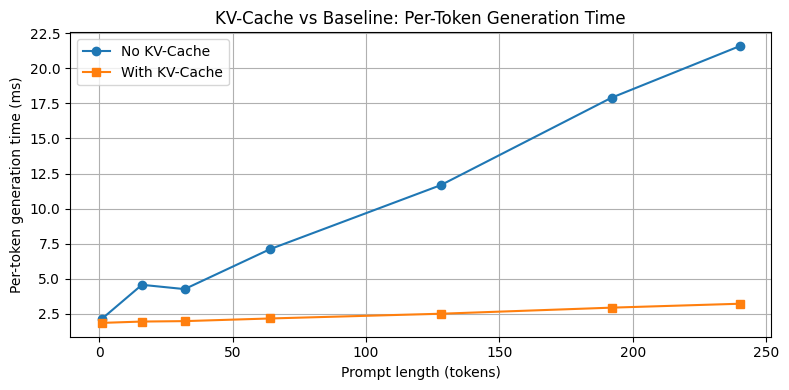

Saved kvcache_benchmark.png


In [ ]:
def benchmark_generate_cached(model: GPTWithCaching, prompt_len: int,
                               gen_tokens: int = 16, num_runs: int = 20) -> float:
    """Return average per-token generation time (ms) for the cached model."""
    model.eval()
    idx = torch.zeros(1, prompt_len, dtype=torch.long, device=device)

    # Warmup
    for _ in range(3):
        model.generate_with_cache(idx.clone(), max_new_tokens=gen_tokens)

    if device == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(num_runs):
        model.generate_with_cache(idx.clone(), max_new_tokens=gen_tokens)
    if device == 'cuda':
        torch.cuda.synchronize()
    elapsed = (time.perf_counter() - t0) / num_runs * 1e3
    return elapsed / gen_tokens


# Run benchmark
cfg       = GPTConfig()
gpt       = GPT(cfg).to(device).eval()
gpt_cache = GPTWithCaching.from_gpt(gpt).to(device).eval()

prompt_lengths = [1, 16, 32, 64, 128, 192, 240]
baseline_times = [benchmark_generate(gpt, L)             for L in prompt_lengths]
cached_times   = [benchmark_generate_cached(gpt_cache, L) for L in prompt_lengths]

plt.figure(figsize=(8, 4))
plt.plot(prompt_lengths, baseline_times, marker='o', label='No KV-Cache')
plt.plot(prompt_lengths, cached_times,   marker='s', label='With KV-Cache')
plt.xlabel('Prompt length (tokens)')
plt.ylabel('Per-token generation time (ms)')
plt.title('KV-Cache vs Baseline: Per-Token Generation Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('kvcache_benchmark.png', dpi=150)
plt.show()
print('Saved kvcache_benchmark.png')

### Q8 (5 pt)
Submit the graph produced above (`kvcache_benchmark.png`).

### Q9 (5 pt)
Interpret the results. How does KV-caching change the scaling of per-token generation
time with context length? What are the trade-offs (memory, first-token latency, etc.)?

**Answer Q9:**


Based on the benchmark results, here is an interpretation of the performance difference between the baseline and the KV-cached model:

Scaling Analysis
Baseline (No KV-Cache): The per-token generation time scales linearly with the context length. This occurs because the baseline model must recompute the K and V matrices for every token in the sequence at every generation step.

KV-Caching: The per-token generation time remains roughly constant (appearing flat on the graph). This is because the model only computes Q, K, and V for the single new token being generated, while retrieving previous context from memory.

Trade-offs of KV-Caching
While KV-caching provides a significant speedup for long sequences, it introduces specific trade-offs:
Memory Usage - Increase: You must store the K and V tensors for every layer in GPU memory. For large models or long contexts, this "KV-Cache" can consume gigabytes of VRAM.
First-Token Latency - same as baseline
Arithmetic Intensity - Decreases, as decode is a memory bound operation.

---
## Step 4 — Submission

1. Make sure `output_check()` passes.
2. Generate all benchmark graphs using the **T4 GPU** runtime.
3. Submit:
   - This `.ipynb` file (changes only inside Solution Blocks).
   - A PDF report answering **Q1–Q9**, including both graphs.

**Your implementation will be run on our GPUs for private evaluation (30 points).**